## **Implementação de uma rede neural LSTM**

### *Objetivo:* 

Aplicar conceitos de Redes Neurais Recorrentes do tipo LSTM no desenvolvimento de um modelo de *deep learning* para dados sequenciais, como séries temporais, dados financeiros, sensores, consumo, clima, tráfego, texto ou outro conjunto adequado. Preparar o *dataset*, construir janelas temporais quando necessário. Treinar uma LSTM base e realizar um ajuste de hiperparâmetros. Analisar o impacto das escolhas no desempenho do modelo.

### *1. Escolha e Preparação do Dataset*

O dataset que escolhemos para realizar esta atividade foi o [Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume) da *UC Irvine Machine Learning Repository*. A escolha proveio do fato do conjunto de dados já relativamente conhecido para a construção de LSTMs, por se tratar de uma série temporal com uma variável alvo clara. 

A UCI informa que o dataset contém volume horário de tráfego na rodovia I-94, em Minneapolis–St Paul, entre 2012 e 2018, incluindo clima e feriados. A variável alvo é `traffic_volume`; as entradas podem ser histórico de tráfego, temperatura, chuva, neve, nuvens, descrição do clima, hora, dia da semana ou feriado. Logo, vamos tentar prever o tráfego de um intervalo de 24 horas a partir do conjunto de dados fornecidos.




In [81]:
pip install ucimlrepo

In [82]:
# importando o dataset
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
metro_interstate_traffic_volume = fetch_ucirepo(id=492) 
  
# data (as pandas dataframes) 
X = metro_interstate_traffic_volume.data.features 
y = metro_interstate_traffic_volume.data.targets 
  
# metadata 
print(metro_interstate_traffic_volume.metadata) 
  
# variable information 
print(metro_interstate_traffic_volume.variables) 

{'uci_id': 492, 'name': 'Metro Interstate Traffic Volume', 'repository_url': 'https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume', 'data_url': 'https://archive.ics.uci.edu/static/public/492/data.csv', 'abstract': 'Hourly Minneapolis-St Paul, MN traffic volume for westbound I-94. Includes weather and holiday features from 2012-2018.', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 48204, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['traffic_volume'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C5X60B', 'creators': ['John Hogue'], 'intro_paper': None, 'additional_info': {'summary': 'Hourly Interstate 94 Westbound traffic volume for MN DoT ATR station 301, roughly midway between Minneapolis and St Paul, MN. Hourly weath

*1.1 Juntando os dados em um só dataframe*

In [83]:
import pandas as pd
import numpy as np

df = X.copy()
df["traffic_volume"] = y

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


*1.2 Analisando variáveis*

In [84]:
df.shape

(48204, 9)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [86]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


À primeira vista, não há valores ausentes no dataset, o que é ótimo. Mas já vejo que date_time está como tipo `object`, ou seja, texto puro, logo, vamos convertê-la para podermos analisar a sequência temporal. Além disso, apesar de parecer ter muitos valores ausentes na coluna `holiday`, na verdade ela possui o nome dos feriados e `NaN` quando um dia não é feriado, mas vamos transformar isso em 0 para dias comuns e 1 para feriados para simplificar.

*1.3 Convertendo colunas*

In [87]:
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

In [88]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [89]:
print(df["date_time"].min(), df["date_time"].max())


2012-10-02 09:00:00 2018-09-30 23:00:00


Intervalo temporal está correto, confirmando que organizamos o dataframe de acordo com a data e convertemos a coluna corretamente.

In [90]:
df["holiday"] = df["holiday"].astype("string")

holiday_series = pd.Series(df["holiday"])

for index, item in holiday_series.items():
    if pd.isna(item):
        holiday_series[index] = '0'
    elif type(item) is type("string"):
        holiday_series[index] = '1'

holiday_series.value_counts()
## Tipicamente é dito que não é uma boa prática iterar por séries do pandas e que se você está fazendo isso,
## provavelmente está fazendo algo errado. Mas, não consegui pensar em outro jeito de fazer que não fosse trabalhoso.
## Poderia ter feito um map com o nome de cada feriado, mas seria chato demais (┬┬﹏┬┬)

,count
holiday,
0,48143
1,61


In [91]:
df["holiday"] = holiday_series.astype(int)
df.rename(columns={"holiday": "is_holiday"}, inplace=True)
df

,is_holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,0,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,0,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,0,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,0,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,0,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,0,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,0,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,0,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,0,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   is_holiday           48204 non-null  int64         
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  object        
 6   weather_description  48204 non-null  object        
 7   date_time            48204 non-null  datetime64[ns]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 3.3+ MB


Transformação bem-sucedida!

Para finalizar o tratamento de dados, vamos verificar se não há duplicatas.

*1.4 Tratamento de duplicatas*

In [93]:
print(df.duplicated().sum(), "\n", df.isna().sum())

17 
 is_holiday             0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64


In [94]:
df.loc[df.duplicated()]

,is_holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
18697,0,286.290,0.0,0.0,1,Clear,sky is clear,2015-09-30 19:00:00,3679
23851,0,289.060,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,4831
26784,0,289.775,0.0,0.0,56,Clouds,broken clouds,2016-09-21 15:00:00,5365
26980,0,287.860,0.0,0.0,0,Clear,Sky is Clear,2016-09-29 19:00:00,3435
27171,0,279.287,0.0,0.0,56,Clouds,broken clouds,2016-10-07 18:00:00,4642
28879,0,267.890,0.0,0.0,90,Snow,light snow,2016-12-06 18:00:00,4520
29268,0,254.220,0.0,0.0,1,Clear,sky is clear,2016-12-19 00:00:00,420
34711,0,295.010,0.0,0.0,40,Clouds,scattered clouds,2017-06-21 11:00:00,4808
34967,0,292.840,0.0,0.0,1,Clear,sky is clear,2017-06-30 10:00:00,4638
34969,0,294.520,0.0,0.0,1,Clear,sky is clear,2017-06-30 11:00:00,4725


In [95]:
df.loc[df["date_time"] == pd.to_datetime("2018-09-29 19:00:00")]

,is_holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48172,0,280.68,0.0,0.0,90,Clouds,overcast clouds,2018-09-29 19:00:00,3818
48173,0,280.68,0.0,0.0,90,Clouds,overcast clouds,2018-09-29 19:00:00,3818


In [96]:
## Aparentemente existem alguns duplicatas, então vou simplesmente removê-los já que não há sentido para uma análise temporal mantê-los.

df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

Antes de criar as janelas da LSTM, ainda falta um detalhe importante: verificar se ha mais de uma linha para o mesmo horario. Em series temporais, isso atrapalha porque a rede espera uma sequencia ordenada, com um registro por passo de tempo.

In [97]:
df["date_time"].duplicated().sum()

np.int64(7612)

Como existem horários repetidos, vou manter uma única linha por `date_time`. Isso pode ter ocorrido por climas semelhantes terem sido medidos ao mesmo tempo, mas não deve afetar a rede. Para variáveis numéricas, uso a média; para clima em texto, uso a moda; para feriado, mantenho 1 se qualquer linha daquele horario for feriado.

In [98]:
def moda_primeiro_valor(serie):
    return serie.mode().iloc[0]


df = (
    df.sort_values("date_time")
    .groupby("date_time", as_index=False)
    .agg({
        "is_holiday": "max",
        "temp": "mean",
        "rain_1h": "mean",
        "snow_1h": "mean",
        "clouds_all": "mean",
        "weather_main": moda_primeiro_valor,
        "weather_description": moda_primeiro_valor,
        "traffic_volume": "mean",
    })
)

df["traffic_volume"] = df["traffic_volume"].round().astype(int)
df.shape

(40575, 9)

In [99]:
df["date_time"].diff().value_counts().head()

,count
date_time,
0 days 01:00:00,37986
0 days 02:00:00,2192
0 days 03:00:00,201
0 days 04:00:00,59
0 days 05:00:00,33


Agora a base está mais adequada para a rede, sem valores ausentes, sem duplicatas exatas e sem horários repetidos numa mesma data. 

Já que o dataframe utiliza o tipo `datetime` do pandas, precisamos quebrar o tempo em colunas separadas para que a rede seja capaz de entender separadamente os padrões de hora, dia da semana, mês, etc. 

In [100]:
df["year"] = df["date_time"].dt.year
df["month"] = df["date_time"].dt.month
df["day"] = df["date_time"].dt.day
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek  # segunda=0, domingo=6
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df.head()

,date_time,is_holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,year,month,day,hour,day_of_week,is_weekend
0,2012-10-02 09:00:00,0,288.28,0.0,0.0,40.0,Clouds,scattered clouds,5545,2012,10,2,9,1,0
1,2012-10-02 10:00:00,0,289.36,0.0,0.0,75.0,Clouds,broken clouds,4516,2012,10,2,10,1,0
2,2012-10-02 11:00:00,0,289.58,0.0,0.0,90.0,Clouds,overcast clouds,4767,2012,10,2,11,1,0
3,2012-10-02 12:00:00,0,290.13,0.0,0.0,90.0,Clouds,overcast clouds,5026,2012,10,2,12,1,0
4,2012-10-02 13:00:00,0,291.14,0.0,0.0,75.0,Clouds,broken clouds,4918,2012,10,2,13,1,0


No notebook de exemplo de LSTM que vimos duranta a aula, as métricas de preço são normalizadas, o que funciona, mas aqui não podemos simplesmente normalizar por se tratar de uma escala temporal. Por exemplo, os dias são cíclicos, 23h é próximo de 00h, mas caso façamos a normalização, a rede vai entender que 23h é muito longe de 00h. Portanto, precisamos usar uma escala **cíclica**, ou seja, utilizamos seno e cosseno, já que variam entre 0 e 1.

In [101]:
## 2πr = comprimento da circunferência de raio cuja hora vai definir
## / 24 = para definir o intervalo de 24h
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["days_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["days_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df.head()

,date_time,is_holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,year,...,day,hour,day_of_week,is_weekend,hour_sin,hour_cos,days_of_week_sin,days_of_week_cos,month_sin,month_cos
0,2012-10-02 09:00:00,0,288.28,0.0,0.0,40.0,Clouds,scattered clouds,5545,2012,...,2,9,1,0,7.071068e-01,-0.707107,0.781831,0.62349,-0.866025,0.5
1,2012-10-02 10:00:00,0,289.36,0.0,0.0,75.0,Clouds,broken clouds,4516,2012,...,2,10,1,0,5.000000e-01,-0.866025,0.781831,0.62349,-0.866025,0.5
2,2012-10-02 11:00:00,0,289.58,0.0,0.0,90.0,Clouds,overcast clouds,4767,2012,...,2,11,1,0,2.588190e-01,-0.965926,0.781831,0.62349,-0.866025,0.5
3,2012-10-02 12:00:00,0,290.13,0.0,0.0,90.0,Clouds,overcast clouds,5026,2012,...,2,12,1,0,1.224647e-16,-1.000000,0.781831,0.62349,-0.866025,0.5
4,2012-10-02 13:00:00,0,291.14,0.0,0.0,75.0,Clouds,broken clouds,4918,2012,...,2,13,1,0,-2.588190e-01,-0.965926,0.781831,0.62349,-0.866025,0.5


### *2. LSTM base com PyTorch*

Nesta etapa, vamos criar uma LSTM simples antes de mexer em hiperparâmetros. A ideia é usar as últimas 24 observações para prever o `traffic_volume` da próxima hora.

Como a LSTM recebe números, precisamos transformar as colunas categóricas em colunas binárias e escalar as variáveis numéricas. A escala será ajustada somente no treino para evitar data leaking durante a validação.

OBS: Decidi ir um pouco além e tentei fazer uma LSTM multivariada já que o dataset possui vários campos além do horário que podem influenciar o `traffic_volume`.

In [102]:
pip install torch scikit-learn matplotlib

In [103]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

## Na hora de selecionar o kernel do collab sugiro colocar uma GPU, com a CPU demora mais de 10 MINUTOS enquanto com GPU e CUDA da NVIDEA é questão de 1 ou 2 minutos  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

Para uma LSTM multivariada, a entrada precisa ter várias colunas obviamente. Usamos o histórico do próprio tráfego, as variáveis climáticas, feriado/fim de semana e os ciclos de hora, dia da semana e mês. Não usamos `date_time` por motivos já citados antes.

In [104]:
feature_cols = [
    "traffic_volume",
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "is_holiday",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "days_of_week_sin",
    "days_of_week_cos",
    "month_sin",
    "month_cos",
]

model_df = df[feature_cols + ["weather_main", "weather_description"]].copy()

# Usamos o get_dummies do pandas que é semelhante a um one-hot encoding
# O método analisa uma coluna categórica e cria uma nova coluna para cada categoria única.
# Ele preenche essas novas colunas com 1 se a categoria original pertencer àquela linha, e 0 se não.

model_df = pd.get_dummies(
    model_df,
    columns=["weather_main", "weather_description"],
    dtype=float,
)

model_df.head()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all,is_holiday,is_weekend,hour_sin,hour_cos,days_of_week_sin,...,weather_description_scattered clouds,weather_description_sky is clear,weather_description_smoke,weather_description_snow,weather_description_thunderstorm,weather_description_thunderstorm with heavy rain,weather_description_thunderstorm with light drizzle,weather_description_thunderstorm with light rain,weather_description_thunderstorm with rain,weather_description_very heavy rain
0,5545,288.28,0.0,0.0,40.0,0,0,7.071068e-01,-0.707107,0.781831,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4516,289.36,0.0,0.0,75.0,0,0,5.000000e-01,-0.866025,0.781831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4767,289.58,0.0,0.0,90.0,0,0,2.588190e-01,-0.965926,0.781831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5026,290.13,0.0,0.0,90.0,0,0,1.224647e-16,-1.000000,0.781831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4918,291.14,0.0,0.0,75.0,0,0,-2.588190e-01,-0.965926,0.781831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


A divisão treino/teste/valid. precisa respeitar o tempo. Por isso, não usamos `train_test_split` com embaralhamento: o treino fica no começo da série, a validação no meio e o teste no final.

In [105]:
train_end = int(len(model_df) * 0.70)
# 70% para treino
val_end = int(len(model_df) * 0.85)
# 15% para validação
# 15% para teste
target_col = "traffic_volume"

train_df = model_df.iloc[:train_end]
val_df = model_df.iloc[train_end:val_end]
test_df = model_df.iloc[val_end:]

train_df.shape, val_df.shape, test_df.shape

((28402, 56), (6086, 56), (6087, 56))

In [106]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(train_df) # fit APENAS no treino
X_val_scaled = feature_scaler.transform(val_df)
X_test_scaled = feature_scaler.transform(test_df)

y_train_scaled = target_scaler.fit_transform(train_df[[target_col]]).ravel() # fit APENAS no treino e fazemos um ravel para transformar tudo num arrayzão, o que facilita na hora da rede "checar o gabarito" por assim dizer
y_val_scaled = target_scaler.transform(val_df[[target_col]]).ravel()
y_test_scaled = target_scaler.transform(test_df[[target_col]]).ravel()

Agora vem a parte mais importante para uma LSTM: transformar a tabela em janelas. Cada `X` terá o formato `(24, num_de_variaveis)`, e cada `y` será o tráfego da hora seguinte. Ou seja, é um neurônio que se duplica 24 vezes para prever a vigésima quinta com memória a longo e curto prazo, uma rede LSTM!

In [107]:
def criar_janelas(features, target, window_size):
    X, y = [], []

    for i in range(window_size, len(features)):
        X.append(features[i - window_size:i])
        y.append(target[i])
    
    # Em suma, converte a lista de janelas em array numérico no formato esperado pela LSTM.
    # Esse reshape(-1, 1) é importante porque o modelo também retorna previsões nesse formato, uma previsão por linha. 
    # O -1 significa “calcule automaticamente quantas linhas são necessárias”.
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)


window_size = 24

X_train, y_train = criar_janelas(X_train_scaled, y_train_scaled, window_size)

X_val_context = np.vstack([X_train_scaled[-window_size:], X_val_scaled])
y_val_context = np.concatenate([y_train_scaled[-window_size:], y_val_scaled])
X_val, y_val = criar_janelas(X_val_context, y_val_context, window_size)

X_test_context = np.vstack([X_val_scaled[-window_size:], X_test_scaled])
y_test_context = np.concatenate([y_val_scaled[-window_size:], y_test_scaled])
X_test, y_test = criar_janelas(X_test_context, y_test_context, window_size)

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((28378, 24, 56),
 (28378, 1),
 (6086, 24, 56),
 (6086, 1),
 (6087, 24, 56),
 (6087, 1))

No PyTorch, o `Dataset` guarda os dados e o `DataLoader` entrega pequenos lotes para o treinamento. A LSTM continua vendo a ordem dentro de cada janela; o `shuffle=True` so muda a ordem dos lotes de treino.

In [108]:
class TrafficDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 64

train_loader = DataLoader(TrafficDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TrafficDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TrafficDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

A classe abaixo é a rede em si. O `nn.LSTM` lê a sequência; depois pegamos apenas a saída do último passo da janela e passamos por uma camada linear (perceptron) para gerar uma previsão numérica.

In [109]:
class LSTMBase(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.linear(out)


model = LSTMBase(n_features=X_train.shape[2]).to(DEVICE)
model

LSTMBase(
  (lstm): LSTM(56, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)

Para a LSTM base, usamos uma configuração fixa e simples com erro quadrático médio como função de perda para penalizar ainda mais erros grandes e Adam como otimizador por ser padrão e por tender a ser mais eficiente em conjuntos de dados pequenos/médios. Depois, na etapa de hiperparâmetros, podemos testar tamanho da janela, número de camadas, neurônios, taxa de aprendizado e tamanho do lote.

In [110]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def calcular_loss(model, loader):
    model.eval()
    losses = []

# with torch.no_grad():
# Isso significa: “execute o código abaixo sem guardar informações para backpropagation”.
# Durante o treino, o PyTorch precisa guardar operações para depois calcular os gradientes e atualizar os pesos. Mas na validação/teste/previsão, 
# só queremos medir o resultado do modelo, não treiná-lo. Então torch.no_grad() para economizar memória e tempo.
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            pred = model(X_batch)
            losses.append(loss_fn(pred, y_batch).item())

    return np.mean(losses)

In [111]:
epochs = 20
history = {"train_loss": [], "val_loss": []}

for epoch in range(epochs):
    model.train()
    train_losses = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = calcular_loss(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch + 1:02d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Epoch 01/20 | train_loss=0.1967 | val_loss=0.0702
Epoch 02/20 | train_loss=0.0774 | val_loss=0.0379
Epoch 03/20 | train_loss=0.0639 | val_loss=0.0358
Epoch 04/20 | train_loss=0.0575 | val_loss=0.0329
Epoch 05/20 | train_loss=0.0530 | val_loss=0.0300
Epoch 06/20 | train_loss=0.0500 | val_loss=0.0278
Epoch 07/20 | train_loss=0.0462 | val_loss=0.0314
Epoch 08/20 | train_loss=0.0439 | val_loss=0.0269
Epoch 09/20 | train_loss=0.0416 | val_loss=0.0292
Epoch 10/20 | train_loss=0.0400 | val_loss=0.0276
Epoch 11/20 | train_loss=0.0385 | val_loss=0.0295
Epoch 12/20 | train_loss=0.0366 | val_loss=0.0262
Epoch 13/20 | train_loss=0.0355 | val_loss=0.0261
Epoch 14/20 | train_loss=0.0346 | val_loss=0.0257
Epoch 15/20 | train_loss=0.0327 | val_loss=0.0279
Epoch 16/20 | train_loss=0.0317 | val_loss=0.0268
Epoch 17/20 | train_loss=0.0311 | val_loss=0.0277
Epoch 18/20 | train_loss=0.0304 | val_loss=0.0249
Epoch 19/20 | train_loss=0.0286 | val_loss=0.0268
Epoch 20/20 | train_loss=0.0279 | val_loss=0.0266


Fazemos uma plotagem rápida para ver como foi a curva de perda

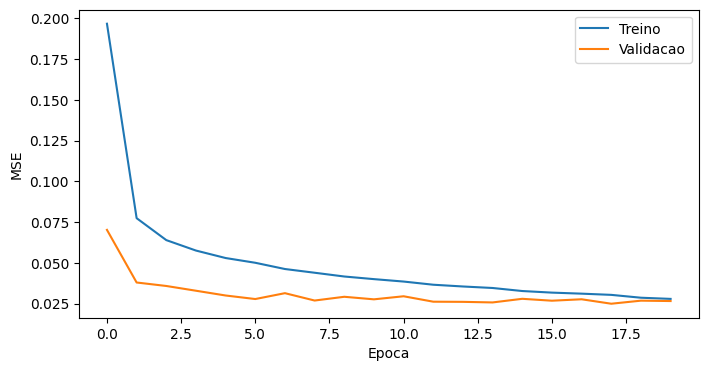

In [112]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Treino")
plt.plot(history["val_loss"], label="Validacao")
plt.xlabel("Epoca")
plt.ylabel("MSE")
plt.legend()
plt.show()

Pelas curvas de erro, a rede apresentou um bom desempenho geral. A perda de treino diminui de forma consistente ao longo das épocas, enquanto a perda de validação também permanece baixa e relativamente estável. Como as duas curvas ficam próximas e a validação se mantém, não há sinais claros de overfitting. Também não parece haver underfitting, pois o erro cai bem e o modelo consegue aprender o padrão temporal dos dados.

Por fim, voltamos as previsões para a escala original de veículos por hora pois assim as métricas ficam mais fáceis de interpretar.

In [113]:
def prever(model, loader):
    model.eval()
    preds, reais = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            pred = model(X_batch).cpu().numpy()
            preds.append(pred)
            reais.append(y_batch.numpy())

    return np.vstack(preds), np.vstack(reais)


pred_scaled, y_scaled = prever(model, test_loader)

pred = target_scaler.inverse_transform(pred_scaled)
y_real = target_scaler.inverse_transform(y_scaled)

mae = mean_absolute_error(y_real, pred)
rmse = mean_squared_error(y_real, pred) ** 0.5

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 214.36
RMSE: 304.25


In [114]:
resultado = pd.DataFrame({
    "real": y_real.ravel(),
    "previsto": pred.ravel(),
})

resultado.head()

,real,previsto
0,5810.0,5792.509277
1,6305.0,6213.187988
2,5657.0,6011.921387
3,4503.0,4800.150879
4,3516.0,3462.120605


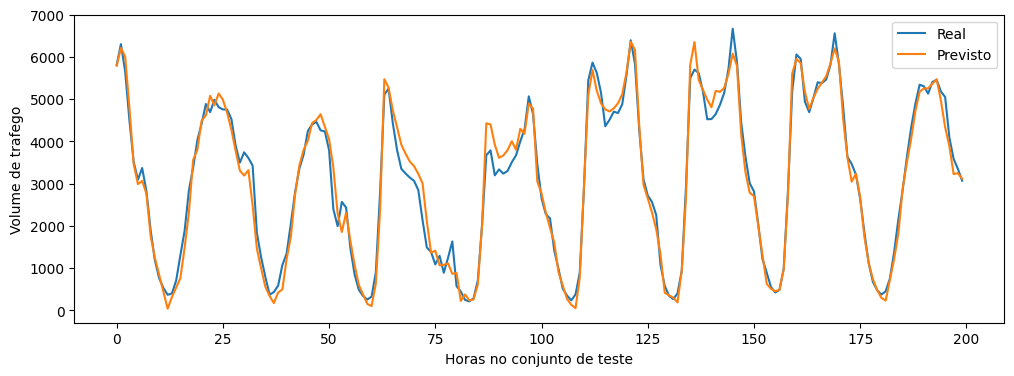

In [115]:
plt.figure(figsize=(12, 4))
plt.plot(resultado["real"].iloc[:200].values, label="Real")
plt.plot(resultado["previsto"].iloc[:200].values, label="Previsto")
plt.xlabel("Horas no conjunto de teste")
plt.ylabel("Volume de trafego")
plt.legend()
plt.show()

### *3. Ajuste de hiperparâmetros com Optuna*

A lauda sugere GridSearch, que é uma escolha válida e fácil de entender. Porém, neste caso, cada combinação exige treinar uma LSTM, então testar todas as possibilidades fica caro rapidamente. Por isso, usamos a outra recomendação: o **Optuna**, que faz uma busca mais inteligente. Ele testa algumas combinações, observa quais tiveram menor erro de validação e usa esse histórico para sugerir novas combinações mais promissoras.

Na prática, em vez de testar tudo em força bruta, o Optuna tenta gastar mais tempo nas regiões do espaço de hiperparâmetros que parecem melhores.

In [116]:
pip install optuna

In [117]:
import optuna
import random

SEED = 42

def fixar_semente(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

O Optuna trabalha com uma função chamada `objective`. Essa função recebe uma tentativa (`trial`), escolhe hiperparâmetros, treina um modelo com eles e devolve uma métrica para minimizar. Aqui, a métrica será o `val_loss`, ou seja, o MSE no conjunto de validação.

Também usamos `pruning`: se uma tentativa começa a ir muito mal nas primeiras épocas, o Optuna pode interrompê-la antes do fim.

In [118]:
class LSTMOptuna(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, dropout):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.linear(out)


def montar_janelas(window_size):
    X_train_trial, y_train_trial = criar_janelas(X_train_scaled, y_train_scaled, window_size)

    X_val_context = np.vstack([X_train_scaled[-window_size:], X_val_scaled])
    y_val_context = np.concatenate([y_train_scaled[-window_size:], y_val_scaled])
    X_val_trial, y_val_trial = criar_janelas(X_val_context, y_val_context, window_size)

    X_test_context = np.vstack([X_val_scaled[-window_size:], X_test_scaled])
    y_test_context = np.concatenate([y_val_scaled[-window_size:], y_test_scaled])
    X_test_trial, y_test_trial = criar_janelas(X_test_context, y_test_context, window_size)

    return X_train_trial, y_train_trial, X_val_trial, y_val_trial, X_test_trial, y_test_trial


def criar_loaders(X_train_trial, y_train_trial, X_val_trial, y_val_trial, X_test_trial, y_test_trial, batch_size):
    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader_trial = DataLoader(
        TrafficDataset(X_train_trial, y_train_trial),
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
    )
    val_loader_trial = DataLoader(TrafficDataset(X_val_trial, y_val_trial), batch_size=batch_size, shuffle=False)
    test_loader_trial = DataLoader(TrafficDataset(X_test_trial, y_test_trial), batch_size=batch_size, shuffle=False)

    return train_loader_trial, val_loader_trial, test_loader_trial


def treinar_modelo(model, train_loader, val_loader, optimizer, epochs, trial=None):
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = calcular_loss(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if trial is not None:
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return history


def objective(trial):
    fixar_semente()

    window_size = trial.suggest_categorical("window_size", [12, 24, 48])
    hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
    num_layers = trial.suggest_int("num_layers", 1, 2)
    dropout = trial.suggest_float("dropout", 0.0, 0.3) if num_layers > 1 else 0.0
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    X_train_trial, y_train_trial, X_val_trial, y_val_trial, X_test_trial, y_test_trial = montar_janelas(window_size)
    train_loader_trial, val_loader_trial, _ = criar_loaders(
        X_train_trial,
        y_train_trial,
        X_val_trial,
        y_val_trial,
        X_test_trial,
        y_test_trial,
        batch_size,
    )

    model_trial = LSTMOptuna(
        n_features=X_train_trial.shape[2],
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
    ).to(DEVICE)

    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=learning_rate)
    history_trial = treinar_modelo(model_trial, train_loader_trial, val_loader_trial, optimizer_trial, epochs=10, trial=trial)

    return min(history_trial["val_loss"])

Como estou usando a GPU no Colab, dá pra usar `n_trials` com 20 ou 30 e `epochs` dentro da função `objective` com 8 ou 10.

In [119]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
)

study.optimize(objective, n_trials=30)

print("Melhor val_loss:", study.best_value)
print("Melhores hiperparâmetros:", study.best_params)

[I 2026-06-09 02:29:01,622] A new study created in memory with name: no-name-df63a8ee-3798-4997-bd93-5ff40d61a6b1
[I 2026-06-09 02:29:14,029] Trial 0 finished with value: 0.02626582759936961 and parameters: {'window_size': 24, 'hidden_size': 32, 'num_layers': 1, 'learning_rate': 0.00190303683817358, 'batch_size': 64}. Best is trial 0 with value: 0.02626582759936961.
[I 2026-06-09 02:29:40,684] Trial 1 finished with value: 0.024679699527460554 and parameters: {'window_size': 12, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.12958350559263473, 'learning_rate': 0.0002692655251486473, 'batch_size': 32}. Best is trial 1 with value: 0.024679699527460554.
[I 2026-06-09 02:29:51,237] Trial 2 finished with value: 0.028231497543553512 and parameters: {'window_size': 48, 'hidden_size': 128, 'num_layers': 1, 'learning_rate': 0.0007896186801026692, 'batch_size': 128}. Best is trial 1 with value: 0.024679699527460554.
[I 2026-06-09 02:30:03,200] Trial 3 finished with value: 0.030017372948350385 

Melhor val_loss: 0.022039822574394446
Melhores hiperparâmetros: {'window_size': 24, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.21870215041229618, 'learning_rate': 0.0013780336485752, 'batch_size': 64}


In [120]:
resultados_optuna = study.trials_dataframe()
resultados_optuna.sort_values("value").head()

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout,params_hidden_size,params_learning_rate,params_num_layers,params_window_size,state
6,6,0.022040,2026-06-09 02:30:21.490966,2026-06-09 02:30:36.603433,0 days 00:00:15.112467,64,0.218702,128,0.001378,2,24,COMPLETE
11,11,0.022205,2026-06-09 02:31:04.265210,2026-06-09 02:31:13.413203,0 days 00:00:09.147993,128,0.219249,128,0.002940,2,12,COMPLETE
21,21,0.022334,2026-06-09 02:32:32.309369,2026-06-09 02:32:59.924928,0 days 00:00:27.615559,32,0.289542,128,0.001405,2,24,COMPLETE
14,14,0.022381,2026-06-09 02:31:24.163121,2026-06-09 02:31:52.029786,0 days 00:00:27.866665,32,0.269658,128,0.001363,2,24,COMPLETE
24,24,0.022412,2026-06-09 02:33:22.188638,2026-06-09 02:33:49.272292,0 days 00:00:27.083654,32,0.248265,128,0.000578,2,24,COMPLETE


Depois da busca, treinamos novamente uma LSTM usando os melhores hiperparâmetros encontrados. Agora usamos mais épocas do que nas tentativas do Optuna, pois essa passa a ser a versão ajustada do modelo.

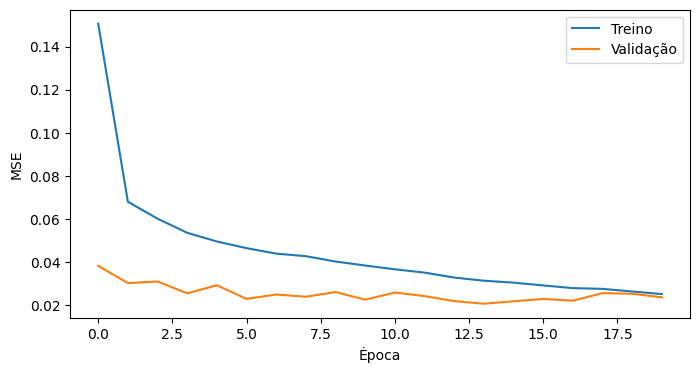

In [121]:
best_params = study.best_params

X_train_best, y_train_best, X_val_best, y_val_best, X_test_best, y_test_best = montar_janelas(best_params["window_size"])
train_loader_best, val_loader_best, test_loader_best = criar_loaders(
    X_train_best,
    y_train_best,
    X_val_best,
    y_val_best,
    X_test_best,
    y_test_best,
    best_params["batch_size"],
)

model_tuned = LSTMOptuna(
    n_features=X_train_best.shape[2],
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout=best_params.get("dropout", 0.0),
).to(DEVICE)

optimizer_tuned = torch.optim.Adam(model_tuned.parameters(), lr=best_params["learning_rate"])
history_tuned = treinar_modelo(model_tuned, train_loader_best, val_loader_best, optimizer_tuned, epochs=20)

plt.figure(figsize=(8, 4))
plt.plot(history_tuned["train_loss"], label="Treino")
plt.plot(history_tuned["val_loss"], label="Validação")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [122]:
pred_tuned_scaled, y_tuned_scaled = prever(model_tuned, test_loader_best)

pred_tuned = target_scaler.inverse_transform(pred_tuned_scaled)
y_tuned_real = target_scaler.inverse_transform(y_tuned_scaled)

mae_tuned = mean_absolute_error(y_tuned_real, pred_tuned)
rmse_tuned = mean_squared_error(y_tuned_real, pred_tuned) ** 0.5

comparacao_modelos = pd.DataFrame({
    "modelo": ["LSTM base", "LSTM ajustada"],
    "MAE": [mae, mae_tuned],
    "RMSE": [rmse, rmse_tuned],
})

comparacao_modelos

,modelo,MAE,RMSE
0,LSTM base,214.357437,304.251618
1,LSTM ajustada,189.389206,285.996845
